# BQ Table EDA

- `tabels.yaml`에 정의된 테이블들을 대상으로 자동 EDA를 수행합니다.
- 테이블 타입(CDC/LOG/SNAPSHOT)을 스키마에서 자동 분류하고, 타입별로 날짜 범위와 처리 방식을 다르게 적용합니다.

| 타입 | 판별 기준 | 기본 기간 | 처리 |
|------|----------|----------|------|
| CDC | `operation` 컬럼 존재 | 7일 | PK 기준 최신 row만 남김 (DELETE 제거) |
| LOG | kalog 데이터셋 | 1일 | 그대로 사용 |
| SNAPSHOT | 그 외 | 1일 | 그대로 사용 |

In [1]:
import sys
sys.path.insert(0, '.')

from google.cloud import bigquery
from bq_eda import (
    load_table_list, run_table_eda, print_eda_summary,
    get_bq_schema, detect_table_type, detect_date_col, detect_cdc_pk,
    classify_columns, deduplicate_cdc, fetch_data,
    eda_numeric, eda_categorical, eda_datetime, eda_json, eda_text,
    plot_numeric, plot_categorical, plot_datetime, plot_text_lengths,
    DEFAULT_DATE_RANGES,
)

client = bigquery.Client(project='service-kurlydata-dev')

/Users/eunji.yeom/Desktop/Gigi/projects/embedding_exp/venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/eunji.yeom/Desktop/Gigi/projects/embedding_exp/venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/eunji.yeom/Desktop/Gigi/projects/embedding_exp/venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning

In [2]:
# yaml에서 테이블 목록 로드
tables = load_table_list('tabels.yaml')

print(len(tables), end='\n\n')
for t in tables:
    print(t['full_id'])

25

bq-marketkurly.kalog.kurly_app
bq-marketkurly.kalog.kurly_app_mweb
bq-marketkurly.kalog.kurly_app_dweb
bq-marketkurly.kalog_raw.DATA-LOGCOLLECT-CLIENT_EVENT
bq-marketkurly.product_collection.product_collections
bq-marketkurly.product_collection.product_collection_items
bq-marketkurly.product_collection.product_categories
bq-marketkurly.product_collection.site_category_groups
bq-marketkurly.product_collection.gd_goods_link
bq-marketkurly.pms.contents_products_view
bq-marketkurly.pms.deal_products_view
bq-marketkurly.pms.master_category_view
bq-marketkurly.pms.master_products
bq-marketkurly.pms.product_descriptions
bq-marketkurly.ord.orders
bq-marketkurly.ord.orderer
bq-marketkurly.ord.order_deal_product
bq-marketkurly.cms.mk_member
bq-marketkurly.cms.mk_member_grp
bq-marketkurly.cms.mk_goods_view
bq-marketkurly.cms.mk_addressbook
bq-marketkurly.cms.mk_goods_view
bq-marketkurly.cms.dsms_contents_product
bq-marketkurly.discount.discount_view
bq-marketkurly.review.gd_goods_review


## 단일 테이블 EDA 실행 예시

- `end_date`: 분석 종료 날짜. 테이블 타입별 기본 기간이 자동 적용됨.
- `start_date`: (선택) 직접 시작 날짜를 지정하면 기본 기간을 무시함.
- `sample_size`: `None`이면 전체 데이터 사용, 필요시 숫자로 제한.

In [3]:
# 분석할 테이블 선택 (인덱스 또는 직접 지정)
# table_idx = 0
table_idx = -8
# table_idx = 12
target = tables[table_idx]
print(f"Target: {target['full_id']}")

Target: bq-marketkurly.cms.mk_member


=== EDA: bq-marketkurly.cms.mk_member ===
  Schema: 30 columns | Type: CDC
  Date filter: pdt [2026-02-23 ~ 2026-03-01]


/Users/eunji.yeom/Desktop/Gigi/projects/embedding_exp/venv/lib/python3.9/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Raw data: 27058 rows x 30 cols
  Dedup (PK=m_no): 27058 -> 27058 rows
  Column types: {'categorical': 18, 'datetime': 6, 'numeric': 2, 'identifier': 1}


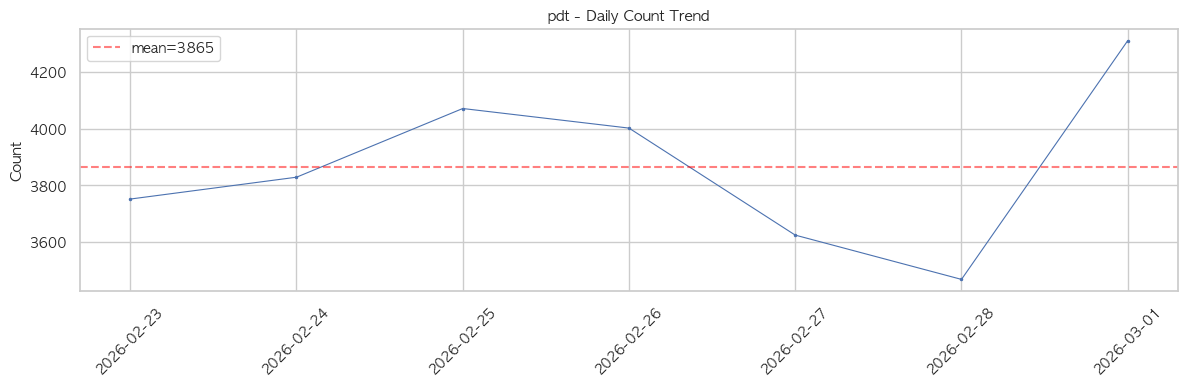

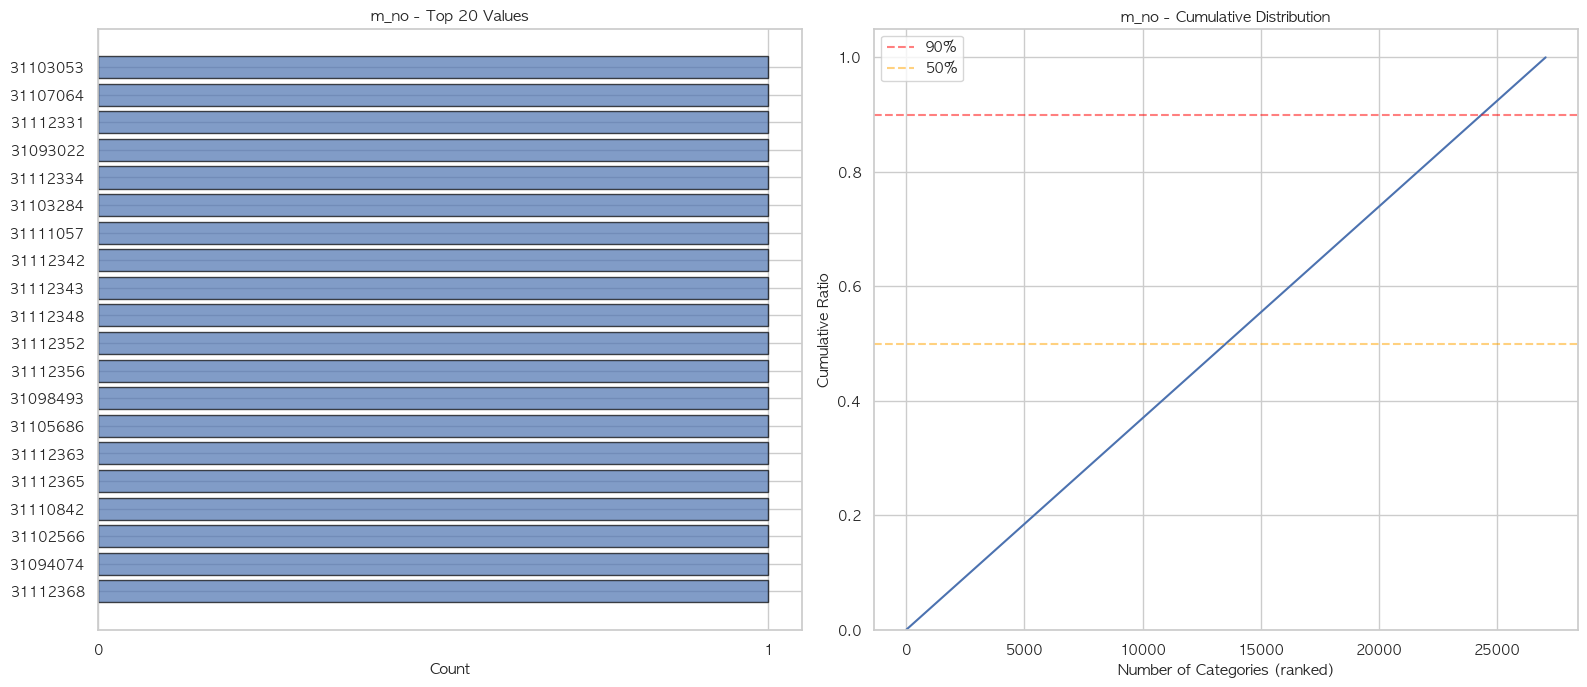

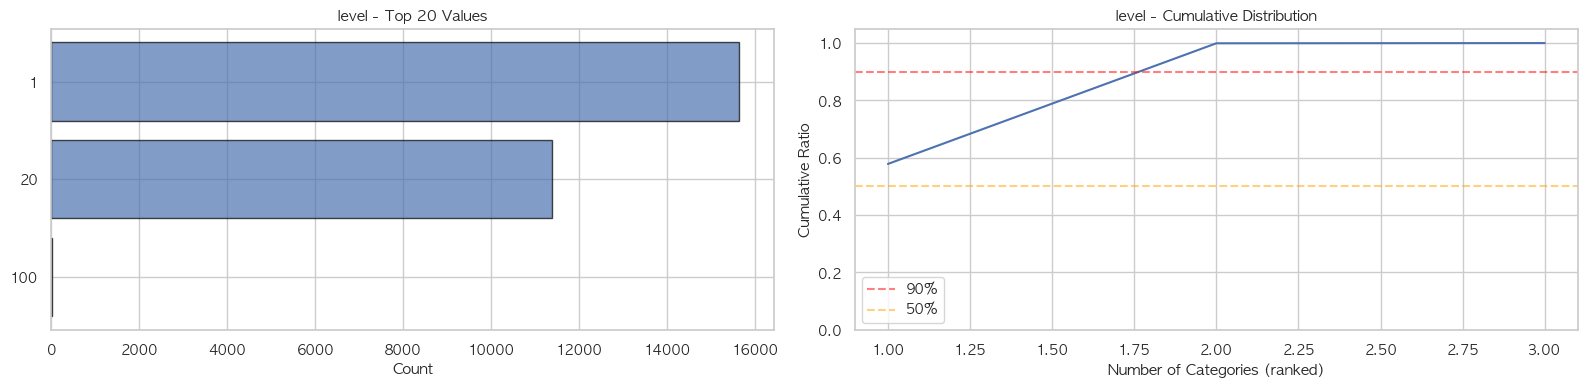

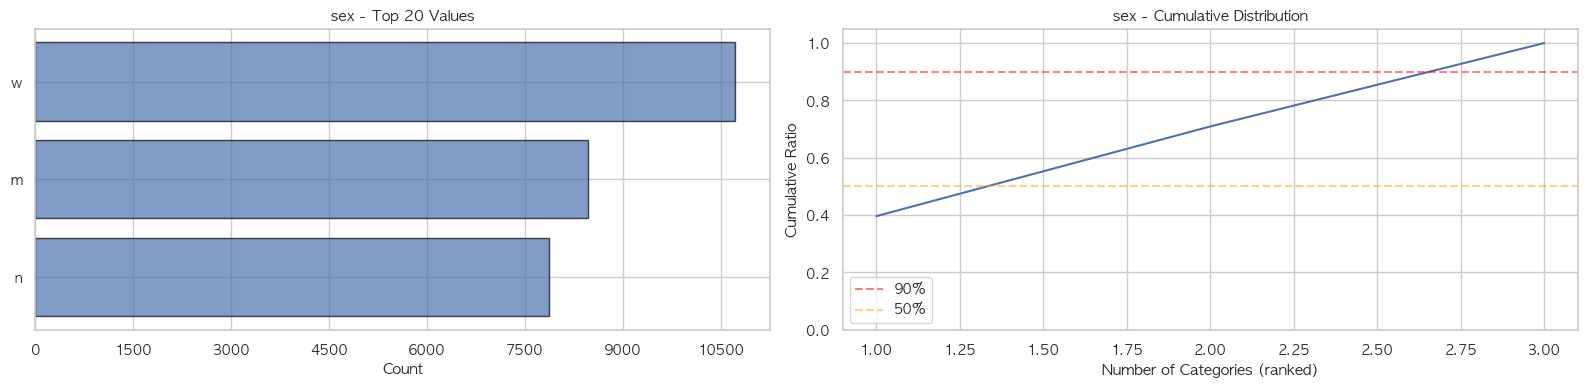

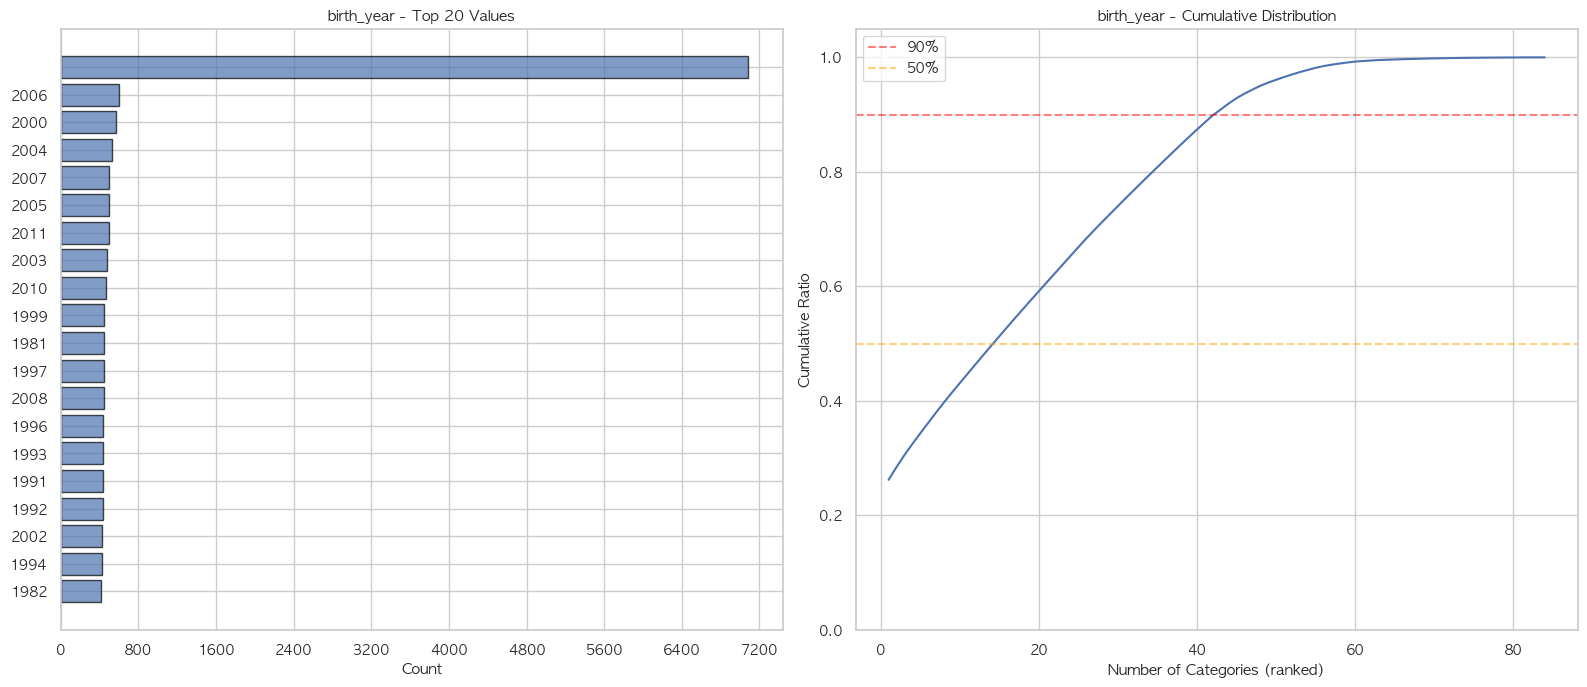

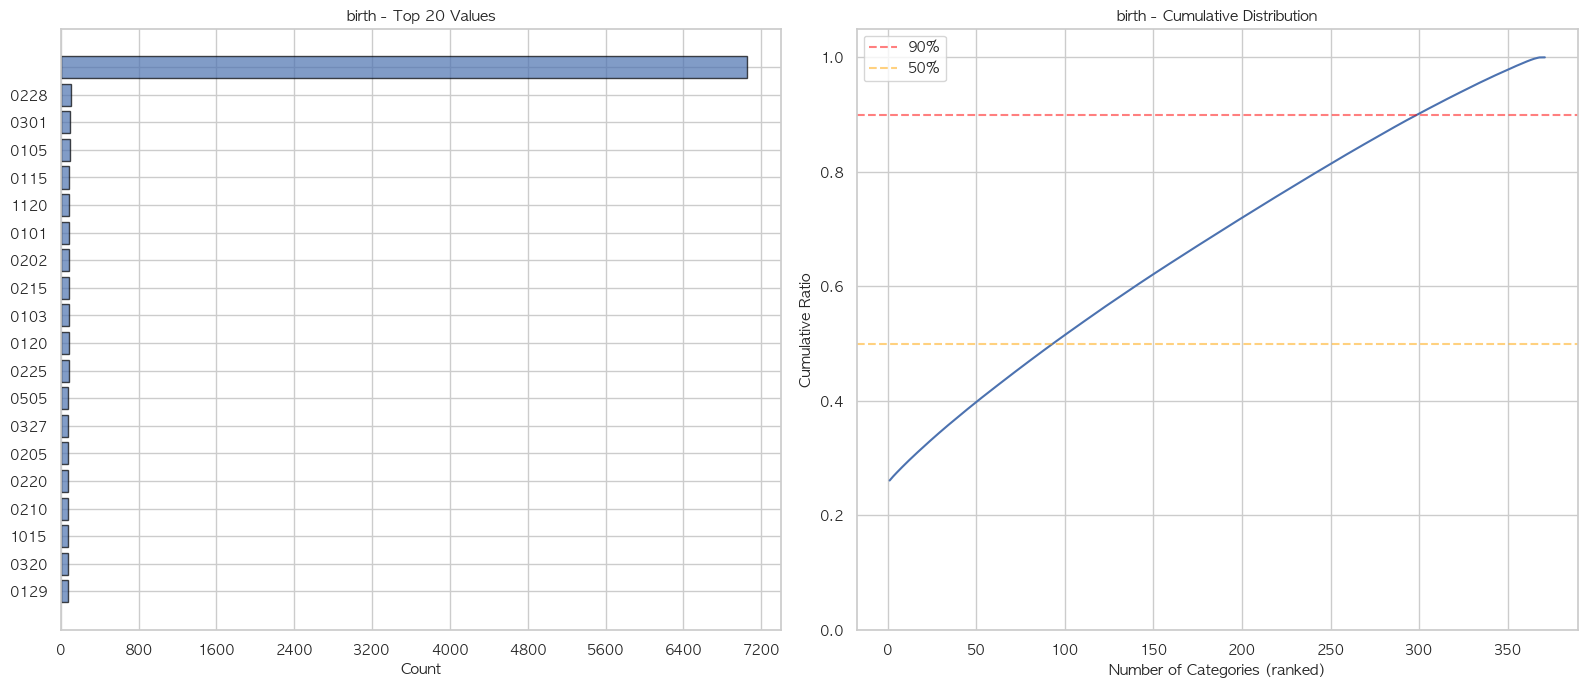

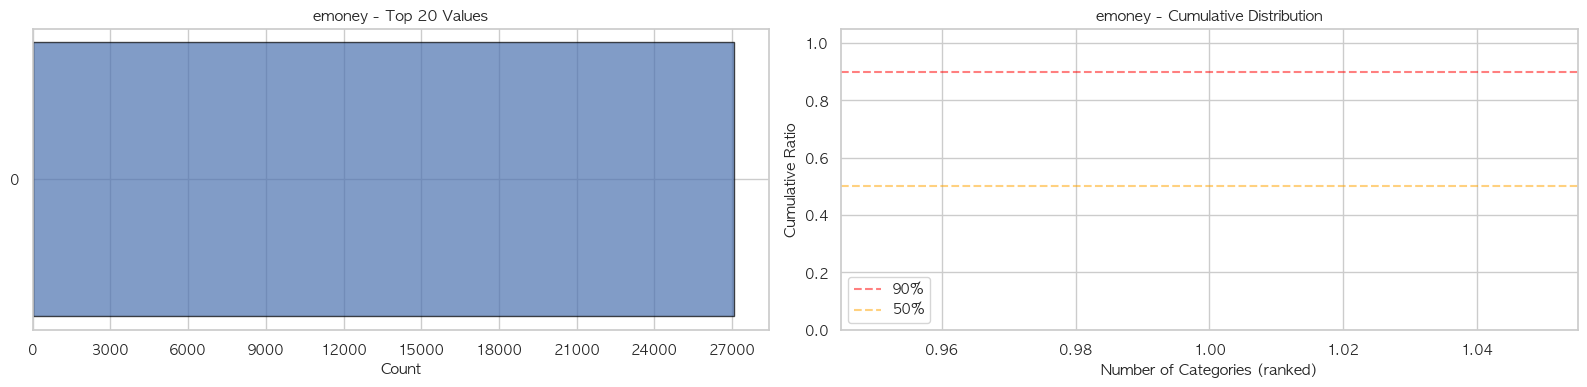

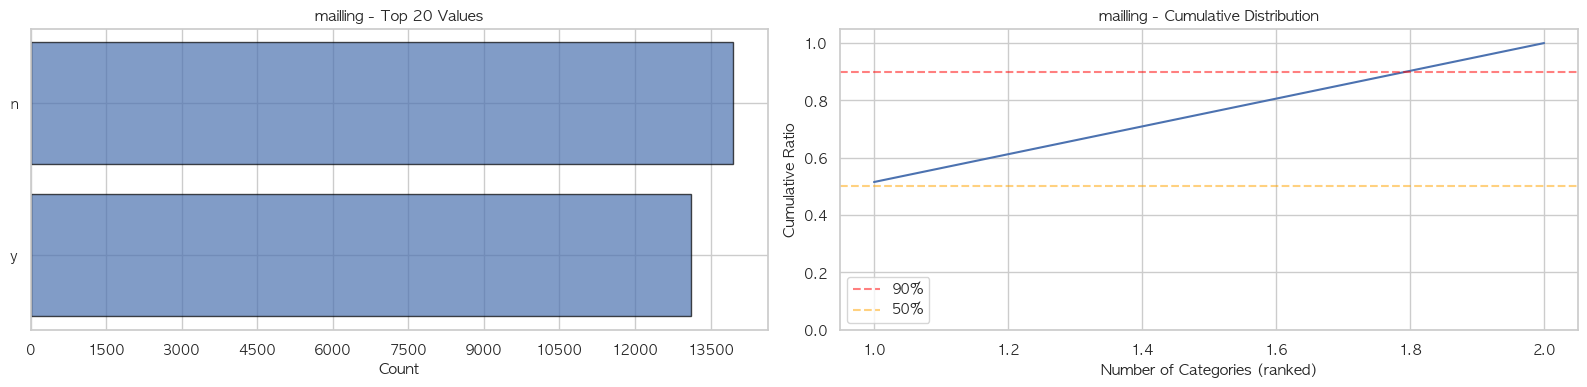

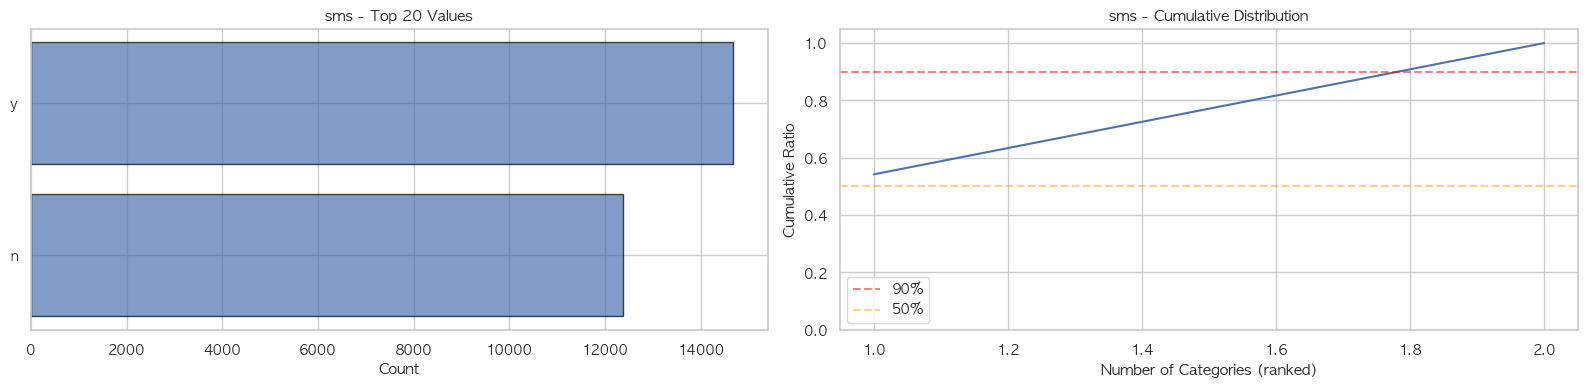

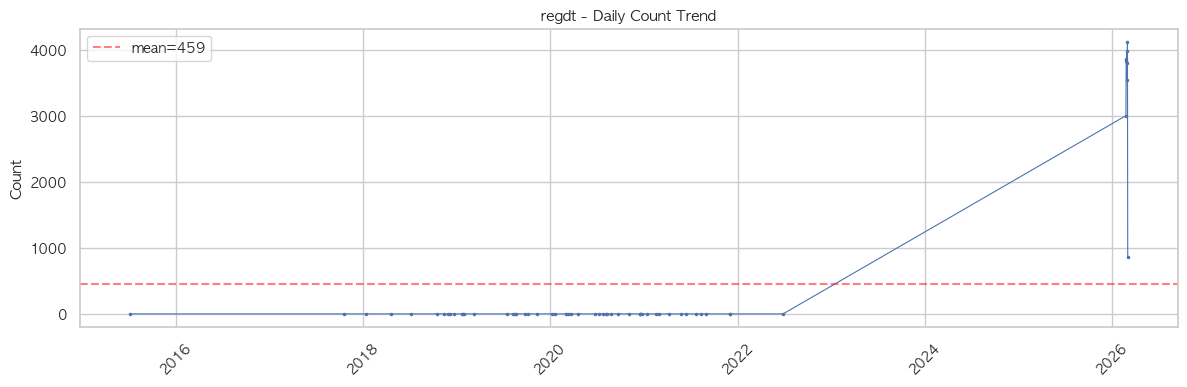

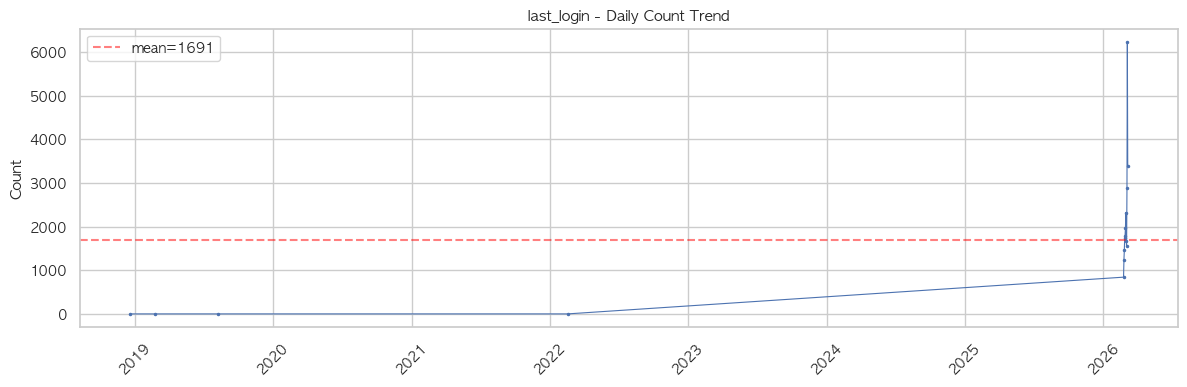

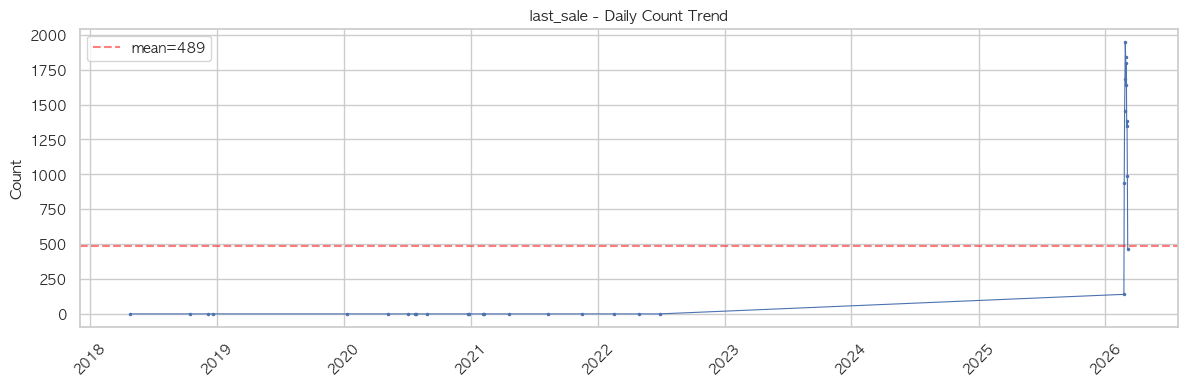

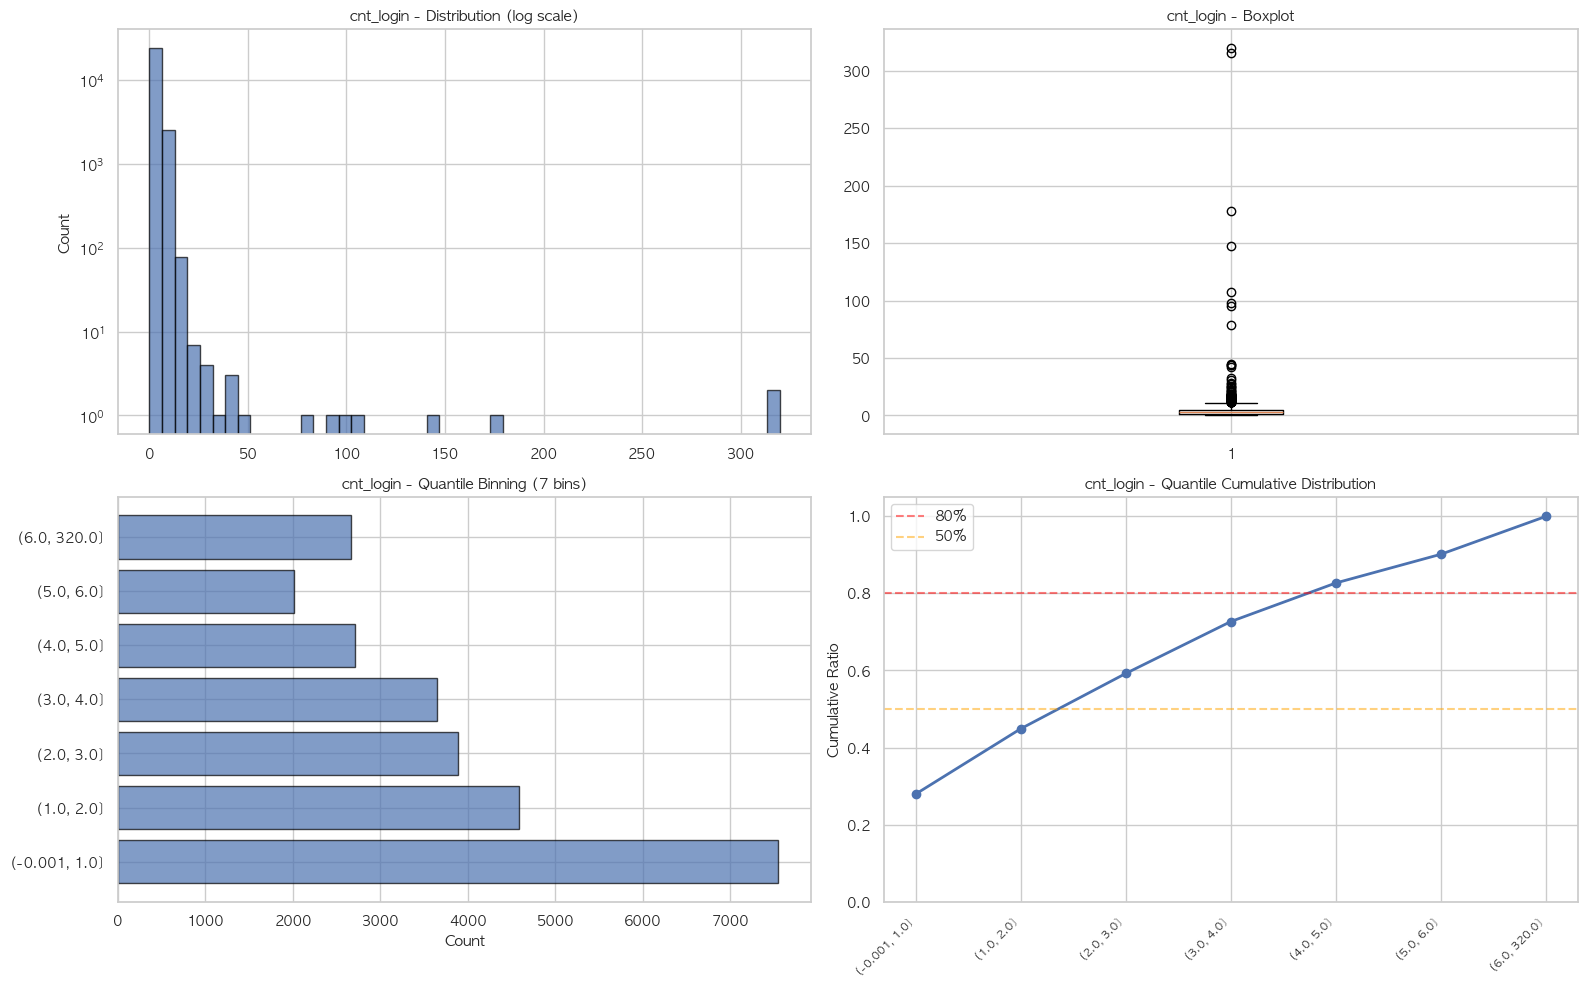

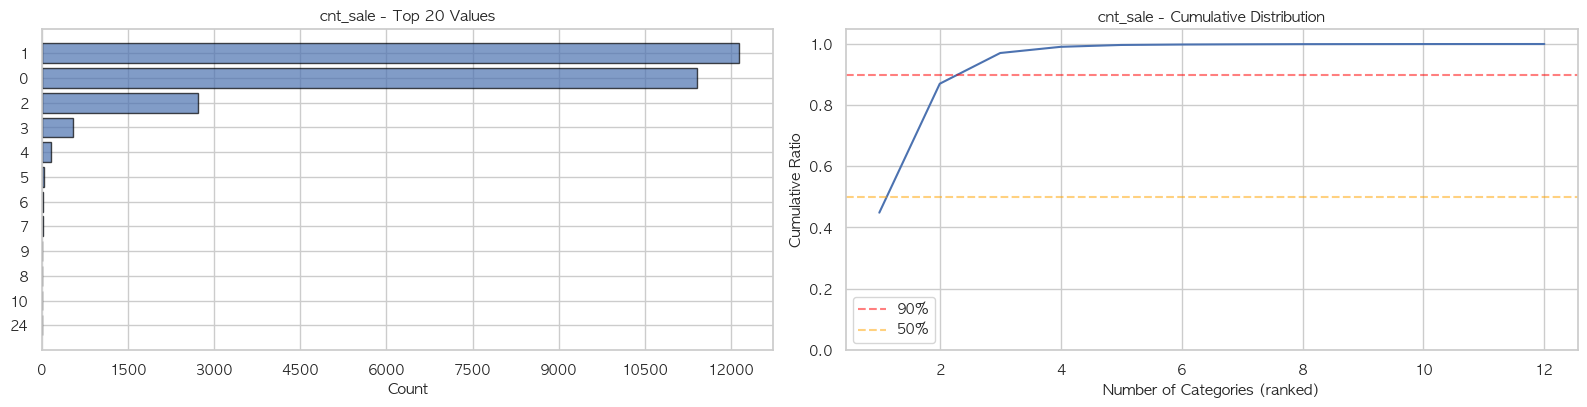

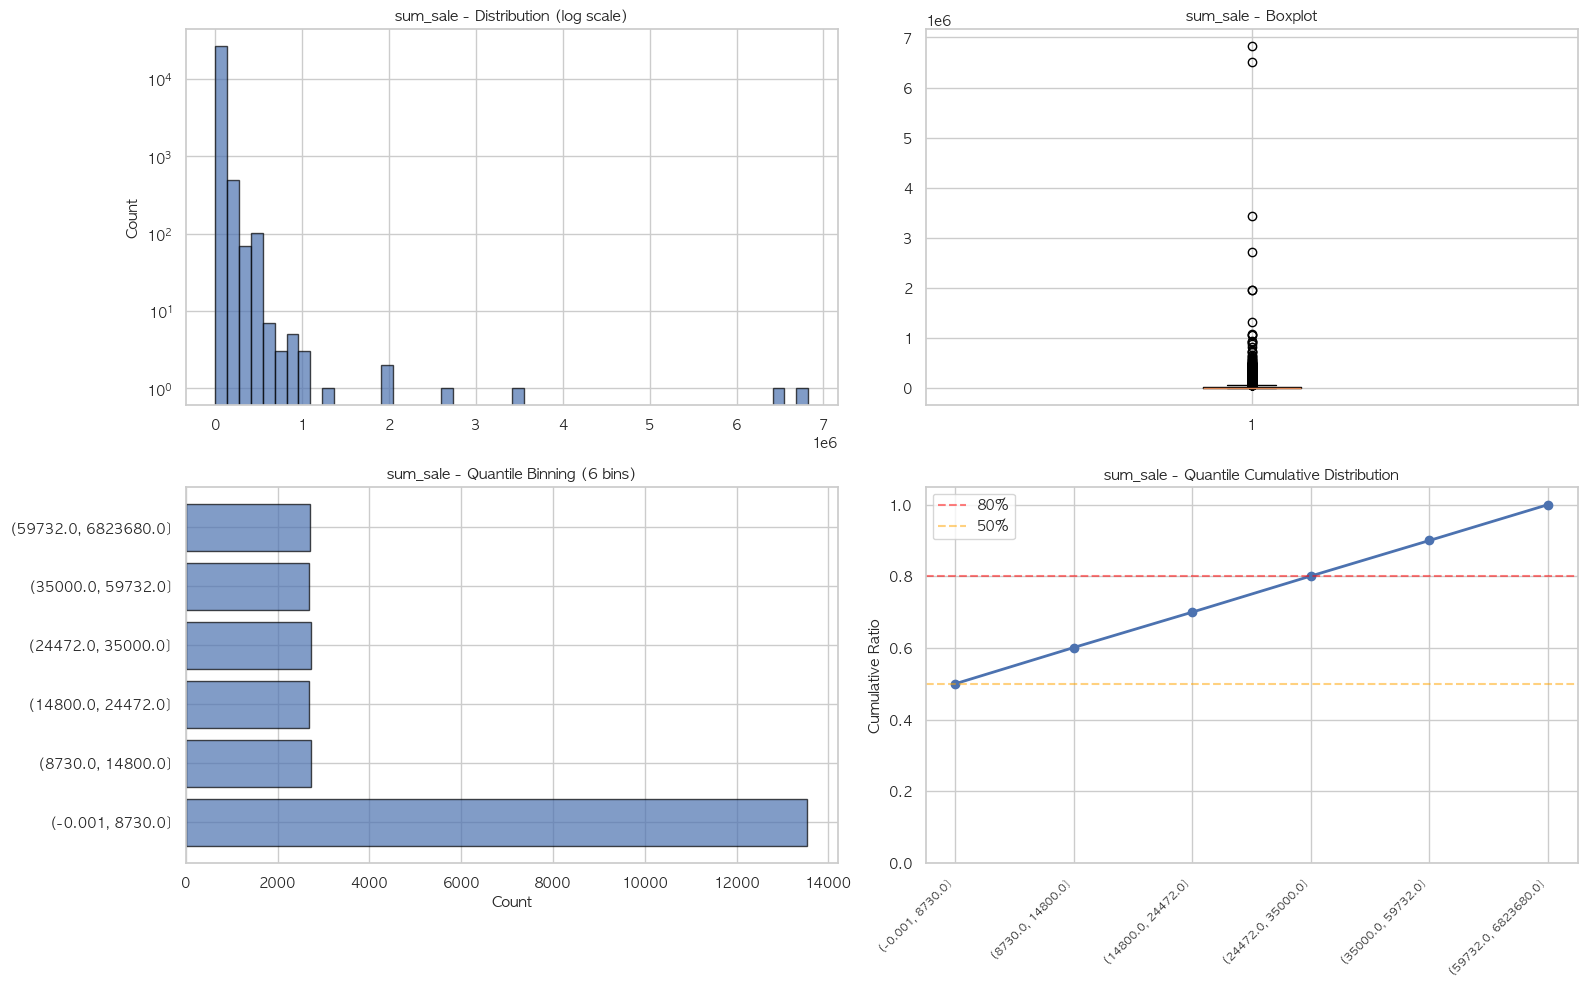

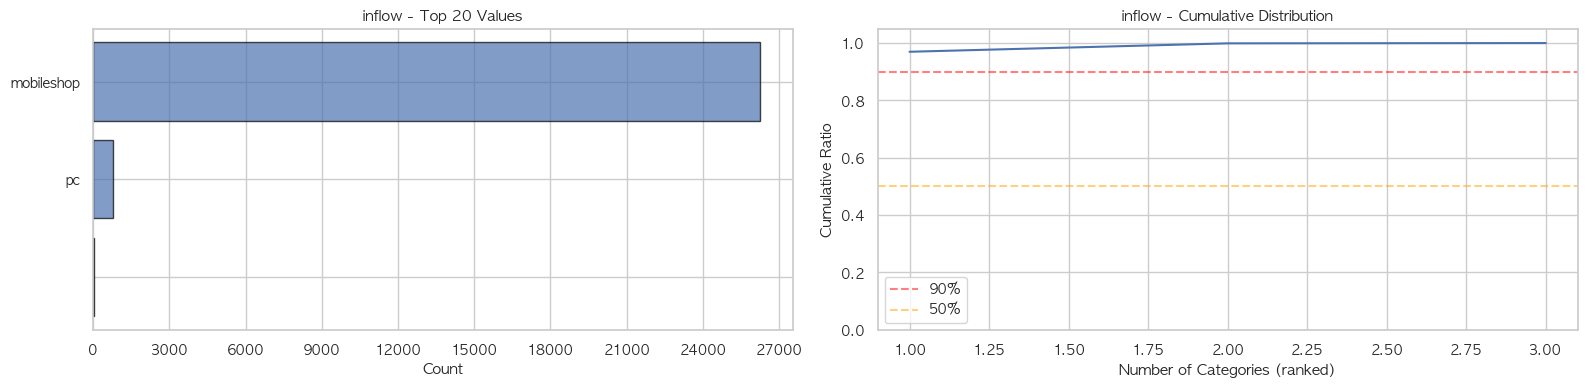

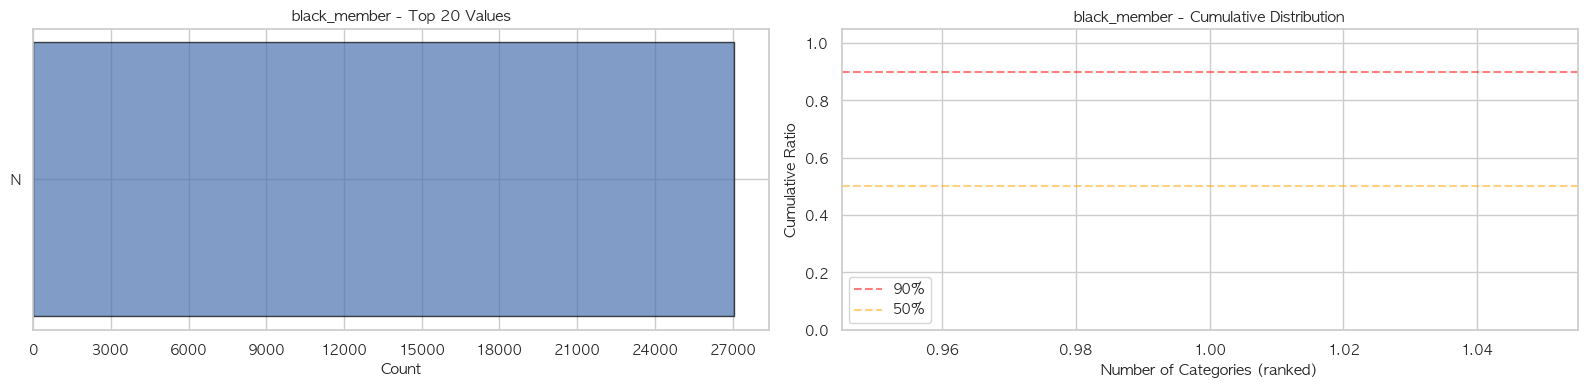

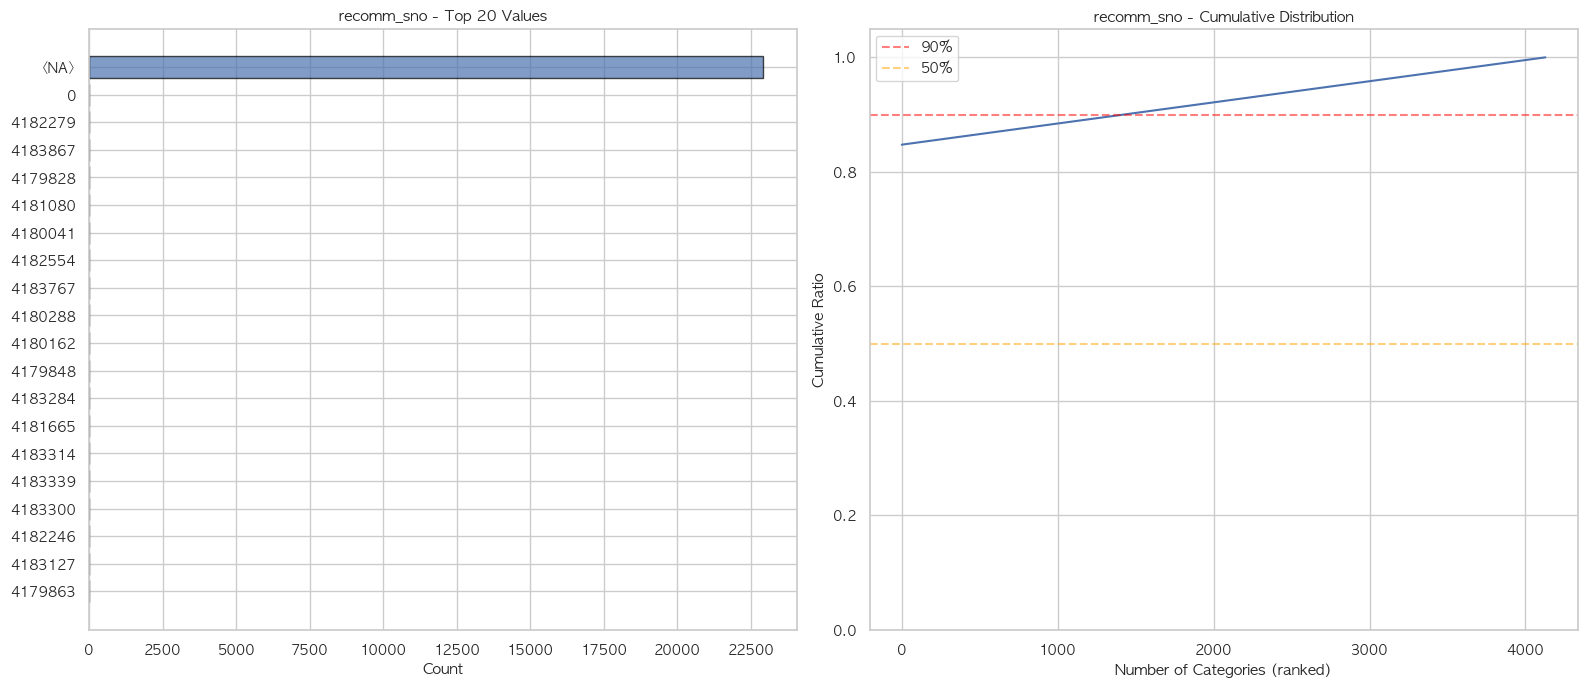

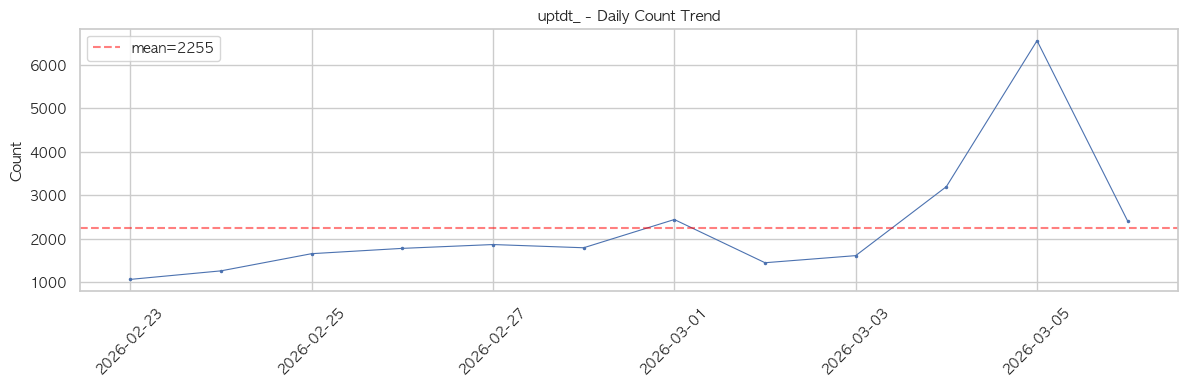

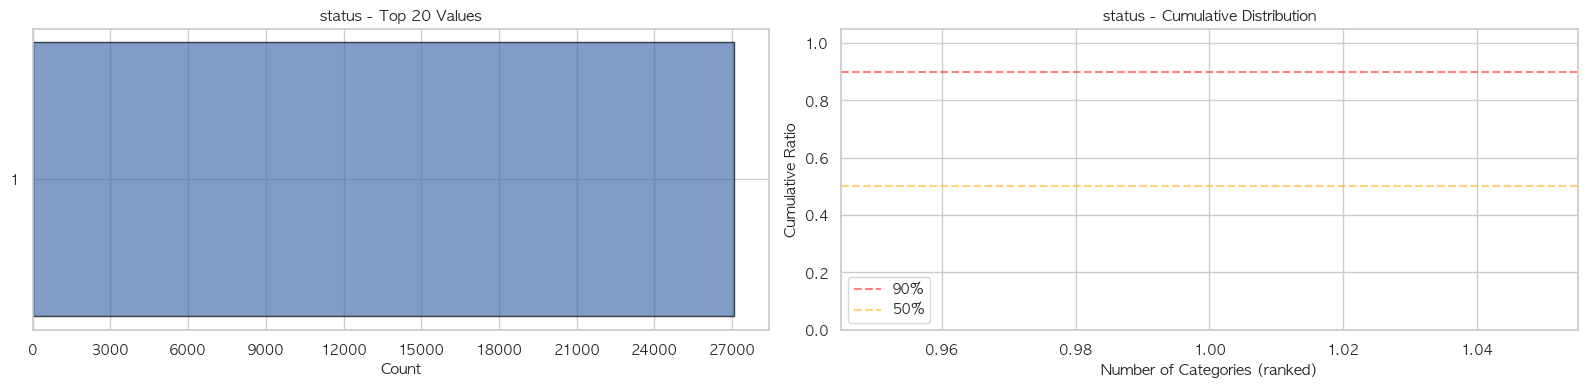

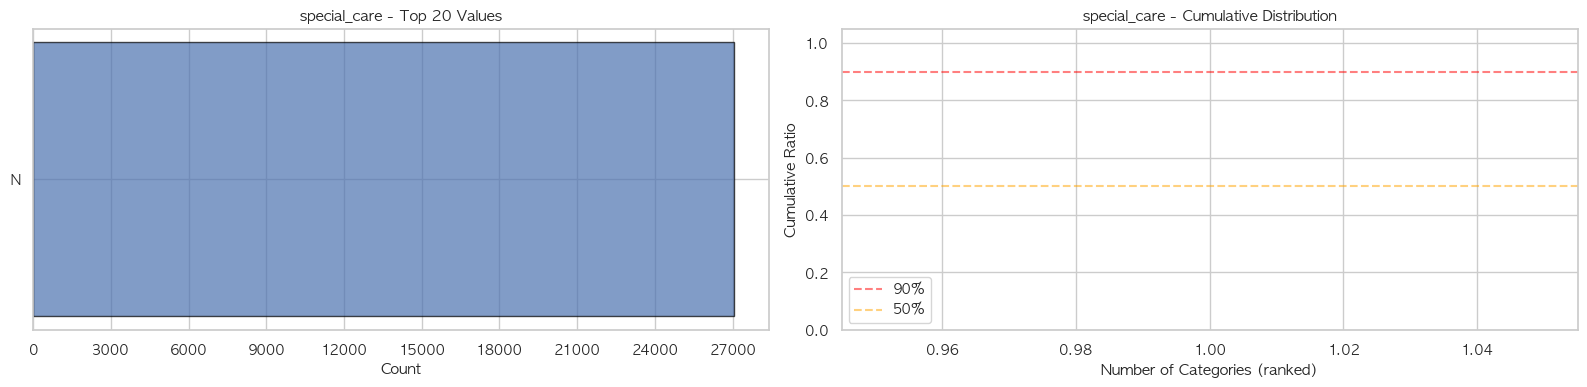

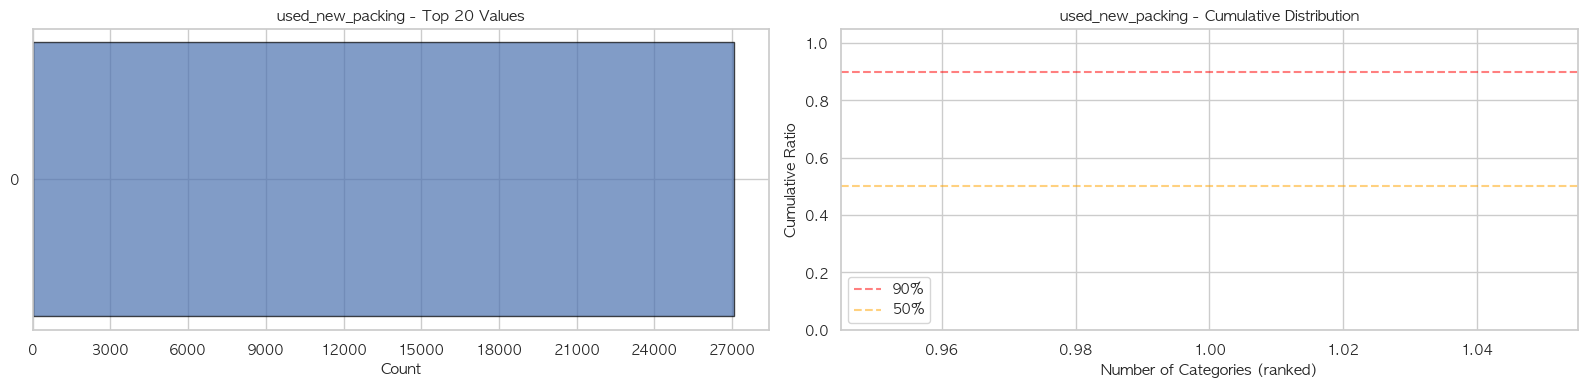

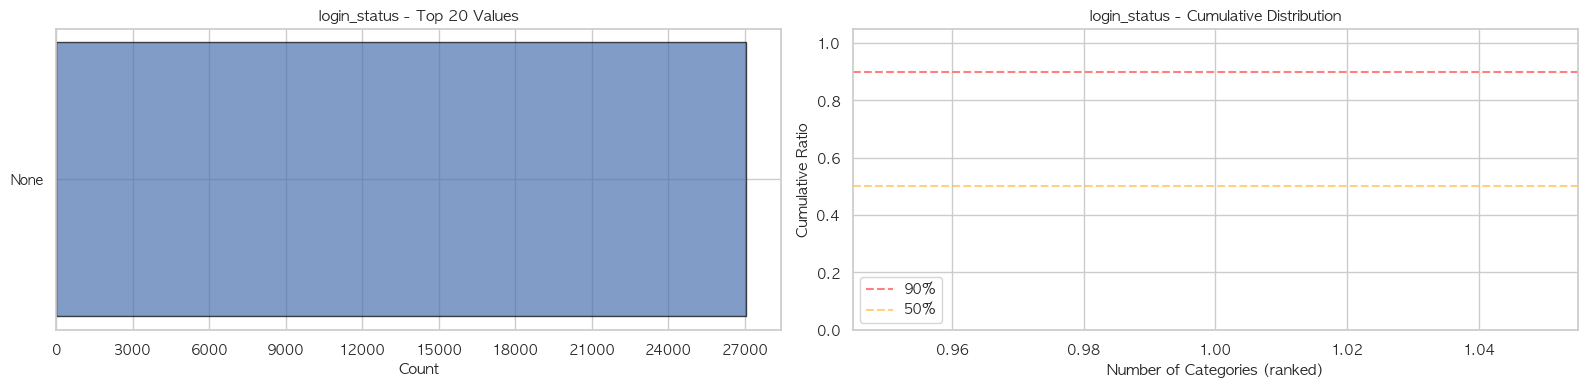

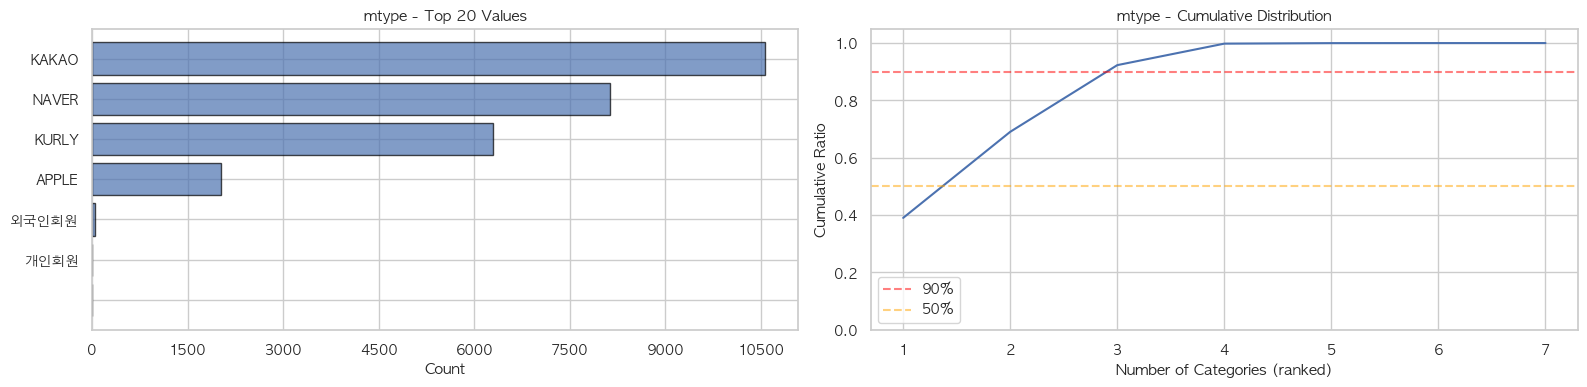

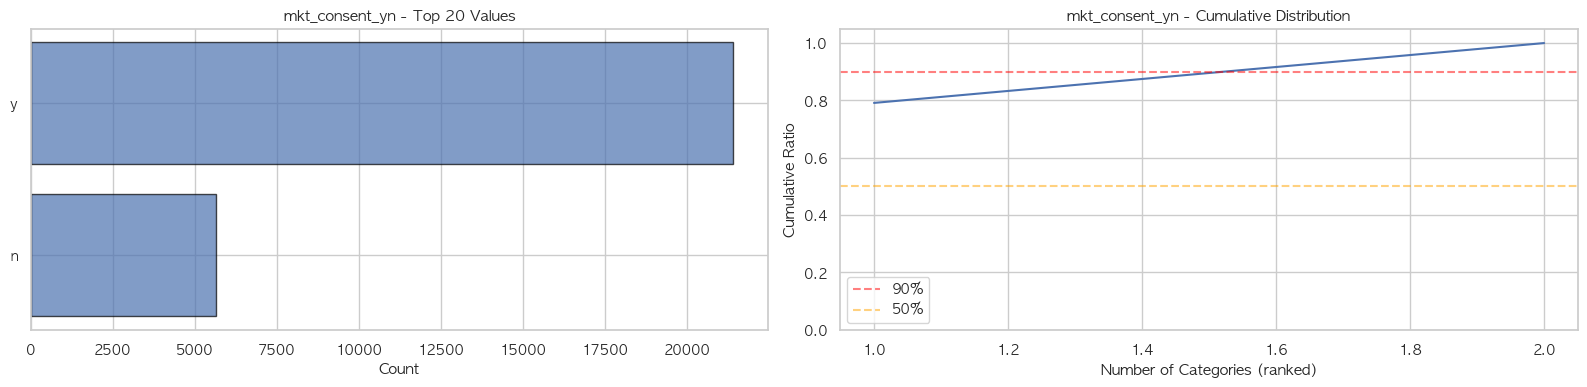

CPU times: user 11.9 s, sys: 2.47 s, total: 14.4 s
Wall time: 10.7 s


In [4]:
%%time

# EDA 실행 - 테이블 타입/날짜 컬럼/날짜 범위/CDC dedup 모두 자동
result = run_table_eda(
    client=client,
    full_table_id=target['full_id'],
    end_date='2026-03-01',
    # start_date='2025-12-01',  # 직접 지정 시 기본 기간 무시
    plot=True,
    top_n_categorical=20,
)

In [5]:
# EDA 결과 요약 출력
print_eda_summary(result['eda_results'])


  [DATETIME] pdt
  Total: 27058  |  Null: 0 (0.0%)
  Range: 2026-02-23 00:00:00 ~ 2026-03-01 00:00:00
  Daily counts - Mean: 3865.43  Median: 3829.0  Std: 285.11  Min: 3469  Max: 4310  Days: 7

  [CATEGORICAL] m_no
  Total: 27058  |  Cardinality: 27058  |  Null: 0 (0.0%)
  Top 20 coverage: 0.1%
    31103053: 1 (0.0%)
    31107064: 1 (0.0%)
    31112331: 1 (0.0%)
    31093022: 1 (0.0%)
    31112334: 1 (0.0%)
    31103284: 1 (0.0%)
    31111057: 1 (0.0%)
    31112342: 1 (0.0%)
    31112343: 1 (0.0%)
    31112348: 1 (0.0%)
  Cumulative: Top 1pct: 1.0% | Top 5pct: 5.0% | Top 10pct: 10.0% | Top 20pct: 20.0% | Top 50pct: 50.0%

  [IDENTIFIER] m_uuid
  Total: 27058  |  Cardinality: 27058  |  UNIQUE  |  Null: 0 (0.0%)
  Samples: ['fe648773-62c6-4023-aac7-2f40180a6997', 'e6dc6e2a-d56c-414f-a5cc-b2897652706c', '92e62ba5-5bc2-4ed6-81c2-78e492901b82', '8b5d4241-08dd-4f8b-8d3e-9100b5a3495d', 'cce4f48f-136f-41b5-9aad-8f02fd7ce01d']

  [CATEGORICAL] level
  Total: 27058  |  Cardinality: 3  |  Null: 

In [6]:
# 컬럼 분류 결과 확인
import pandas as pd
pd.DataFrame(
    [(col, ctype) for col, ctype in result['column_types'].items()],
    columns=['column', 'classified_type']
)

,column,classified_type
0,pdt,datetime
1,m_no,categorical
2,m_uuid,identifier
3,level,categorical
4,sex,categorical
5,birth_year,categorical
6,birth,categorical
7,emoney,categorical
8,mailling,categorical
9,sms,categorical


## 심화 EDA (필요시 수동 실행)

자동 분류가 부정확하거나 추가 분석이 필요한 컬럼은 아래에서 개별 함수를 직접 호출하세요.

In [ ]:
# 예: 특정 컬럼을 강제로 다른 타입으로 분석
df = result['dataframe']

# 수치형 심화: 특정 컬럼 분포를 percentile 단위로 확인
# print(eda_numeric(df, 'id'))
# plot_numeric(df, 'id')

# 범주형 심화: Top N을 늘려서 확인
# print(eda_categorical(df, 'status', top_n=50))
# plot_categorical(df, 'status', top_n=50)

# 시계열 심화
# print(eda_datetime(df, 'created_at'))
# plot_datetime(df, 'created_at')

# JSON 심화: key별 value 분포까지 확인
# print(eda_json(df, 'some_json_col'))

In [ ]:
df.head()

In [ ]:
from collections import Counter

print(len(set(df['id'])), len(df))

Counter(df['id']).most_common(20)

## 전체 테이블 일괄 EDA

In [ ]:
# 모든 테이블을 순회하며 EDA 실행
END_DATE = "2026-03-01"

all_results = {}
for t in tables:
    try:
        r = run_table_eda(
            client=client,
            full_table_id=t['full_id'],
            end_date=END_DATE,
            plot=False,
        )
        all_results[t['full_id']] = r
        print(f"  Done: {t['full_id']} ({r['table_type']}, {r['row_count']} rows)")
    except Exception as e:
        print(f"  FAILED: {t['full_id']} - {e}")
        all_results[t['full_id']] = {'error': str(e)}

In [ ]:
# 전체 테이블 null/sparsity 요약
summary_rows = []
for table_id, r in all_results.items():
    if 'error' in r:
        continue
    for eda in r.get('eda_results', []):
        summary_rows.append({
            'table': table_id.split('.')[-1],
            'column': eda.get('column'),
            'type': eda.get('type'),
            'null_count': eda.get('null_count', 0),
            'null_ratio': eda.get('null_ratio', 0),
        })

summary_df = pd.DataFrame(summary_rows)
# null ratio가 높은 컬럼 순으로 정렬
summary_df.sort_values('null_ratio', ascending=False).head(30)